### Home Task: Implement K-means algorithm

### library

In [21]:
import matplotlib.pyplot as plt 
import numpy as np 

### Data

In [22]:
from sklearn.datasets import make_classification
Xc_2,_= make_classification(n_samples=200,
                                    n_features=2,
                                    n_informative=2,
                                    n_redundant=0,
                                    random_state=0,
                                    n_clusters_per_class=1,
                                    class_sep = 0.8)
 
x = Xc_2[:,0]   
y = Xc_2[:,1]

x[:5], y[:5]


(array([ 0.87033369, -0.27565612,  0.68590571,  1.16581799, -1.0607126 ]),
 array([-1.12915356,  1.07888341,  1.4901946 ,  0.87715301,  0.6950888 ]))

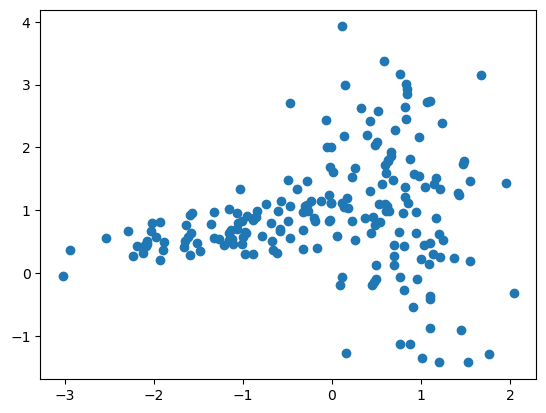

In [23]:
colors = np.array(['green','orange','blue', 'red'])
def plot_points(closest_centroids = None):
    if closest_centroids is None:
        plt.scatter(x,y)
    else:
        plt.scatter(x,y, c= colors[closest_centroids])

        
plt.figure()
plot_points()

### Steps of implementatiion
Initialize K centroids

Assign every point to closest centroid

Compute new centroids as means of samples assigned to corresponding centroid

Implement cost 
 
 
 where 
 is distance from sample 
 to assigned centroid 

Iterate setps 2,3 till cost is stabile

Select the best clustering (with the least cost) from 100 results computed with random centroid initializations

Visualize results (clusters, centroids) for 

Note:

You may need develop couple of additional/intermediate functions
You may track cost changes to make sure the algorithm is working properly

### Initialize K centroids

[[-1  1]
 [ 1  1]
 [ 2  0]
 [ 1  2]]


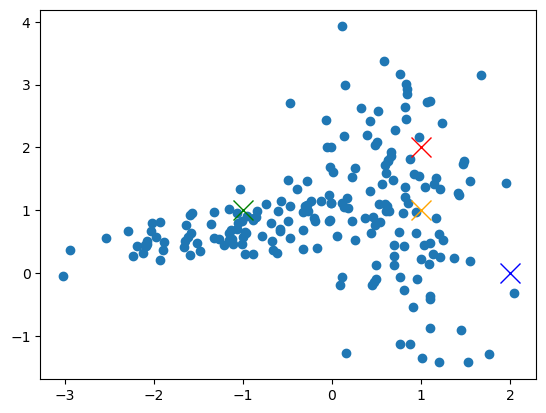

In [24]:
def init_centroids(amount, is_random = True, points = None, seed = 10): 
    if is_random:
        np.random.seed(seed) 
        return points [np.random.choice(len(points), amount)]        
    else:
        centroids = np.array ([(-1,1), (1,1), (2, 0), (1,2) ])
        return centroids[:amount]

# centroids = init_centroids(2, is_random= False)
centroids = init_centroids(4, is_random= False)
print (centroids)

def plot_centroids(centroids):
    for i, c in enumerate (centroids):
        plt.plot(c[0], c[1], marker = 'x', color= colors[i], markersize=14) 

def draw_state(centroids = None, closest_centroids = None):        
    plt.figure ()
    plot_points(closest_centroids)
    plot_centroids(centroids)

draw_state(centroids = centroids, closest_centroids=None)

### Assign every point to closest centroid

In [25]:
# Compute distances from samples to centroids
def compute_distances(samples, centroids):
 
    return np.array([np.apply_along_axis(np.linalg.norm, 1, samples-c) for c in centroids])
 
compute_distances(Xc_2, centroids)

array([[2.83398006, 0.72862655, 1.75572458, 2.16929918, 0.31089686,
        0.95324549, 2.71725317, 0.5431063 , 0.58269413, 1.83490653,
        1.12086269, 2.2626437 , 2.34332789, 0.99386862, 1.21985071,
        1.32676642, 1.18277906, 2.33943988, 1.23007036, 2.23088146,
        1.01518781, 2.11010389, 1.13371544, 1.34666563, 2.15742669,
        2.06347106, 0.69125322, 3.26822072, 0.80697519, 2.50769508,
        2.43846582, 0.39032242, 0.18995849, 0.6939903 , 1.17527891,
        1.94112407, 3.49741785, 1.23032584, 0.46213521, 2.63690065,
        2.27366372, 0.53775082, 1.60359974, 3.58156164, 1.12896194,
        0.36487791, 1.31578434, 0.81140924, 3.0886285 , 1.33561893,
        2.20672347, 2.48334682, 2.57943127, 0.16370633, 2.30703621,
        2.43191099, 1.19964578, 0.56960349, 1.61593478, 2.85683554,
        1.72535222, 0.07824689, 1.85518336, 0.34220371, 0.45108059,
        0.77506132, 0.37414015, 1.83293363, 0.50673258, 3.107798  ,
        2.24280917, 1.19541977, 0.53051065, 2.81

closest_centroids:
 [2 0 1 1 0 0 3 0 0 3 1 1 3 0 0 0 3 1 0 3 0 1 1 1 1 1 0 2 0 2 1 0 0 0 0 1 2
 0 0 3 0 0 1 2 1 0 0 0 2 3 2 2 3 0 3 1 0 0 1 3 1 0 1 0 0 0 0 1 0 2 1 3 0 2
 0 0 0 3 3 0 2 0 0 0 3 1 0 3 3 3 0 3 3 3 0 1 1 3 1 3 3 0 2 1 0 0 0 0 0 3 0
 3 0 3 0 1 3 3 0 3 1 3 3 0 2 1 0 1 0 0 1 3 0 0 0 1 1 1 1 1 1 0 1 0 1 1 1 0
 1 0 0 1 0 0 0 0 3 0 2 3 1 0 1 0 0 3 2 3 0 0 0 1 1 2 1 0 0 1 0 0 0 3 3 0 1
 1 0 3 0 1 1 3 0 0 1 3 3 2 0 1]


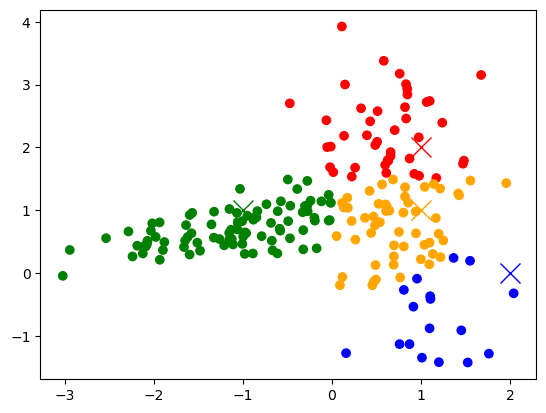

In [26]:
# Step 1 of iteration: compute closest centroids
def compute_closest_centroids(centroids):
    all_distances = compute_distances(Xc_2, centroids)
    closest_centroids = np.apply_along_axis(np.argmin, 0, all_distances)
    return closest_centroids


closest_centroids = compute_closest_centroids(centroids)
print('closest_centroids:\n', closest_centroids)
draw_state(centroids=centroids, closest_centroids=closest_centroids)

### Compute new centroids as means of samples assigned to corresponding centroid

New centroids: [array([-1.10224097,  0.71538415]), array([0.73574771, 0.75621209]), array([ 1.15683017, -0.72543977]), array([0.61582262, 2.26909972])]


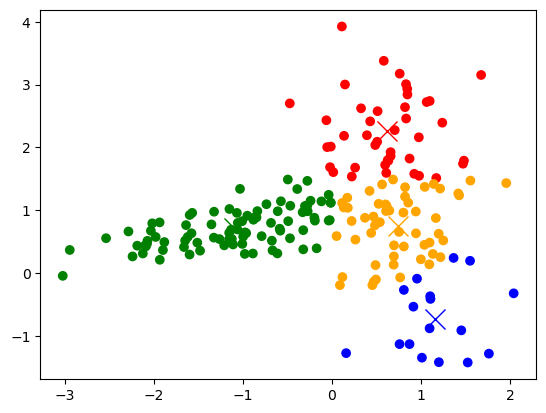

In [27]:
# Step 2 of iteration: compute means:
def compute_means(centroids, closest_centroids):    
    new_centroids = [] 
    for i in range (len(centroids)):
        if i not in closest_centroids: 
            new_centroids.append(centroids[i])
        else: 
            new_centroid= np.mean(Xc_2[np.where(closest_centroids==i)], axis = 0)
            new_centroids.append(new_centroid)
    return new_centroids

centroids = compute_means(centroids, closest_centroids)
print ('New centroids:',centroids) 
draw_state(centroids = centroids, closest_centroids = closest_centroids)

### Implement cost <math xmlns="http://www.w3.org/1998/Math/MathML">
  <mi>J</mi>
  <mo>=</mo>
  <mfrac>
    <mn>1</mn>
    <mi>m</mi>
  </mfrac>
  <munder>
    <mo data-mjx-texclass="OP" movablelimits="false">&#x2211;</mo>
    <mi>i</mi>
  </munder>
  <mo stretchy="false">(</mo>
  <msup>
    <mi>d</mi>
    <mrow data-mjx-texclass="ORD">
      <mo stretchy="false">(</mo>
      <mi>i</mi>
      <mo stretchy="false">)</mo>
    </mrow>
  </msup>
  <msup>
    <mo stretchy="false">)</mo>
    <mrow data-mjx-texclass="ORD">
      <mn>2</mn>
    </mrow>
  </msup>
</math> where <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msup>
    <mi>d</mi>
    <mrow data-mjx-texclass="ORD">
      <mo stretchy="false">(</mo>
      <mi>i</mi>
      <mo stretchy="false">)</mo>
    </mrow>
  </msup>
</math> is distance from sample <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msup>
    <mi>x</mi>
    <mrow data-mjx-texclass="ORD">
      <mo stretchy="false">(</mo>
      <mi>i</mi>
      <mo stretchy="false">)</mo>
    </mrow>
  </msup>
</math>
 to assigned centroid <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msup>
    <mi>c</mi>
    <mrow data-mjx-texclass="ORD">
      <mo stretchy="false">(</mo>
      <mi>i</mi>
      <mo stretchy="false">)</mo>
    </mrow>
  </msup>
</math>

In [28]:
def J(centroids, closest_centroids):

    all_dist = []
    for c_index in set(closest_centroids):
        assigned_samples = Xc_2[np.where(closest_centroids == c_index)]
        all_dist_centroid = compute_distances(
            assigned_samples, [centroids[c_index]])
        all_dist.append(np.sum(all_dist_centroid))
        
    m = len(closest_centroids)
    return 1/m * np.sum(all_dist)

closest_centroids = np.zeros(len(Xc_2), dtype=int)
print('Cost= {}'.format(J(centroids, closest_centroids)))

Cost= 1.5373793860600773


### Iterate setps 2,3 till cost is stabile


The best cost:  0.7059961147793795


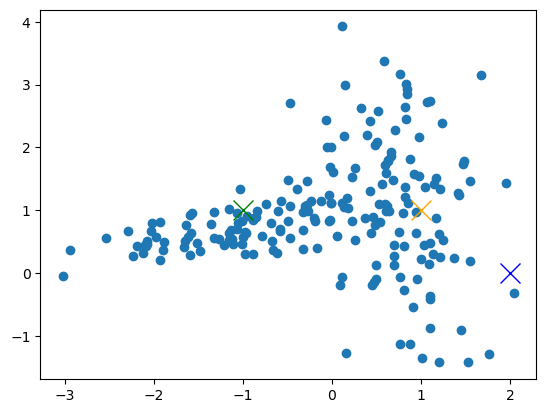

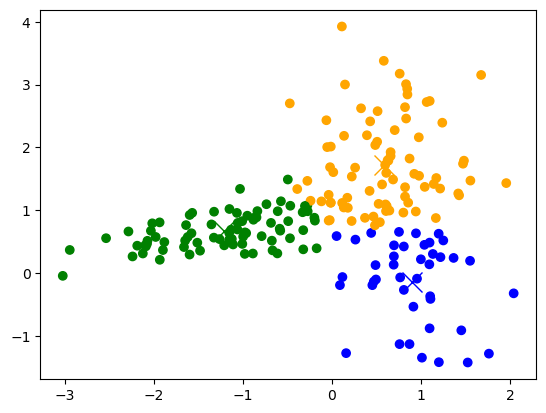

In [29]:
def update(amount,max_iterations = 200,is_randoms = True):
    global closest_centroids
    global centroids
    
    centroids = init_centroids(amount, is_randoms, Xc_2, 2)

    draw_state(centroids)
    cost = 0
    
    for i in range(max_iterations):
        
        closest_centroids = compute_closest_centroids(centroids)
        centroids = compute_means(centroids, closest_centroids)
        new_cost = J(centroids,closest_centroids)
    
        if new_cost == cost:
            break
        else:
            cost = new_cost
    
    draw_state(centroids, closest_centroids)
    return cost
    
cost = update(3,200,False)
print("\nThe best cost: ",cost)

### Select the best clustering (with the least cost) from 100 results computed with random centroid initializations

The best cost:  0.7867506646444796


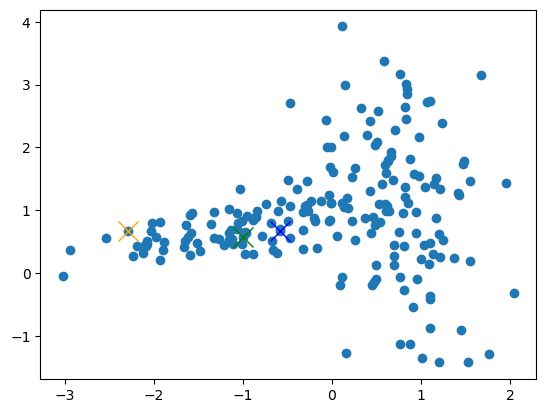

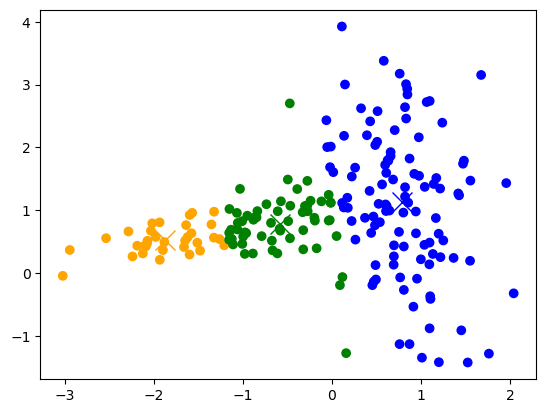

In [30]:
cost = update(3,100,True)
print("The best cost: ",cost)

### Visualize results (clusters, centroids) for <math xmlns="http://www.w3.org/1998/Math/MathML">
  <mi>K</mi>
  <mo>=</mo>
  <mn>4</mn>
</math>

The best cost:  0.6029478215514041


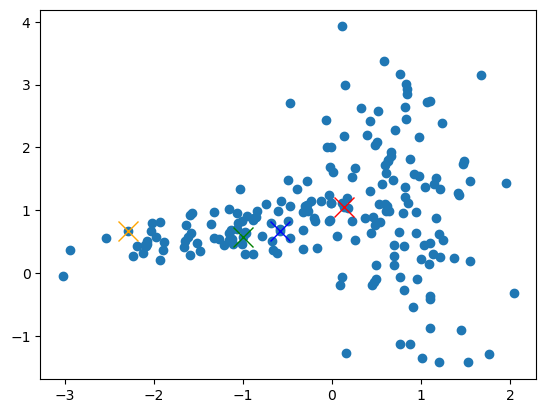

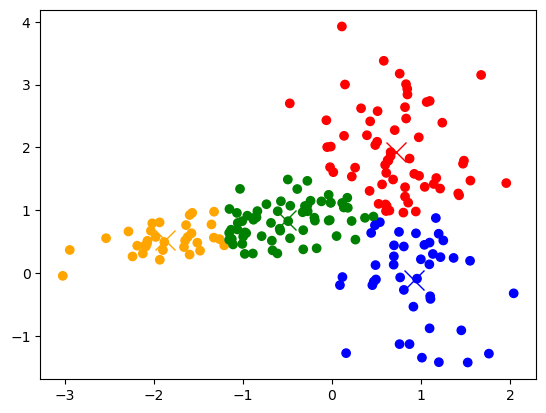

In [31]:
cost = update(4,100,True)
print("The best cost: ",cost)